In [180]:
#IMPORT LIBRARIES
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

from wordcloud import WordCloud

nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/thandoluhlemoyo/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/thandoluhlemoyo/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [182]:
#LOAD DATA 
#SOUTH AFRICAN NEWS ARTICLES
df_sa_n = pd.read_csv("sa_news_articles.csv")
print(df_sa_n.head())
print(df_sa_n.columns)

   article_id       country               date  \
0           1  South Africa  23 September 2025   
1           2  South Africa    5 February 2026   
2           3  South Africa    6 February 2026   
3           4  South Africa   21 February 2026   
4           5  South Africa       3 March 2026   

                                                 URL  \
0  https://mg.co.za/the-green-guardian/2025-09-23...   
1  https://mg.co.za/the-green-guardian/2026-02-05...   
2  https://mg.co.za/the-green-guardian/2026-02-06...   
3  https://mg.co.za/the-green-guardian/2026-02-21...   
4  https://mg.co.za/health/2026-03-03-superbugs-p...   

                                               title  \
0  Governments’ fossil fuel production plans thre...   
1  UPDATED: Komati illustrates the human cost of ...   
2                 ‘King coal is back’, says Mantashe   
3  Climate change an existential threat, Ramaphos...   
4  Superbugs plus climate change equals double tr...   

                         

In [184]:
#UK NEWS ARTICLES
df_uk_n = pd.read_csv("uk_news_articles.csv")
print(df_uk_n.head())
print(df_uk_n.columns)

   article_id         country             date  \
0           1  United Kingdom      22 May 2024   
1           2  United Kingdom     1 April 2025   
2           3  United Kingdom     19 June 2025   
3           4  United Kingdom  13 October 2021   
4           5  United Kingdom     19 July 2024   

                                                 URL  \
0  https://www.independent.co.uk/news/ap-departme...   
1  https://www.independent.co.uk/climate-change/c...   
2  https://www.independent.co.uk/climate-change/n...   
3  https://www.independent.co.uk/climate-change/n...   
4  https://www.independent.co.uk/news/ap-new-york...   

                                               title  \
0  Sites with radioactive material more vulnerabl...   
1  The world is experiencing record heat – this i...   
2  World now in ‘crunch time’ to avoid higher lev...   
3  Climate change is the biggest single health th...   
4  Humans caused climate change. Amid the sufferi...   

                         

In [186]:
#SOUTH AFRICAN BUSINESS ARTICLES
df_sa_b = pd.read_csv("sa_business_articles.csv")
print(df_sa_b.head())
print(df_sa_b.columns)

   article_id       country           date  \
0           1  South Africa   28 July 2024   
1           2  South Africa  24 March 2024   
2           3  South Africa   08 June 2025   
3           4  South Africa   22 June 2025   
4           5  South Africa   27 July 2025   

                                                 URL  \
0  https://www.businessday.co.za/bt/opinion/2024-...   
1  https://www.businessday.co.za/bt/opinion/2024-...   
2  https://www.businessday.co.za/bt/business-and-...   
3  https://www.businessday.co.za/bt/opinion/2025-...   
4  https://www.businessday.co.za/bt/opinion/2025-...   

                                               title  \
0  JOHAN VAN GREUNING: Insurance industry must ch...   
1  ZANDILE MAKHOBA: Climate change turns up the h...   
2        Reserve Bank 'must deal with climate risks'   
3  BJORN LOMBORG: South Africa should not follow ...   
4  SASHA COOK: No time to blow hot and cold over ...   

                                        article_t

In [188]:
#UK BUSINESS ARTICLES
df_uk_b = pd.read_csv("uk_business_articles.csv")
print(df_uk_b.head())
print(df_uk_b.columns)

   article_id         country             date  \
0           1  United Kingdom    02 March 2026   
1           2  United Kingdom      24 Nov 2025   
2           3  United Kingdom     05 June 2025   
3           4  United Kingdom  16 October 2025   
4           5  United Kingdom  19 January 2026   

                                                 URL  \
0  https://www.business-live.co.uk/enterprise/pri...   
1  https://www.business-live.co.uk/economic-devel...   
2  https://www.business-live.co.uk/enterprise/adm...   
3  https://www.business-live.co.uk/economic-devel...   
4  https://www.business-live.co.uk/economic-devel...   

                                               title  \
0  Private sector investment essential for Bristo...   
1  More community, less ‘ivory tower’: Alliance M...   
2  Admiral backs charity dedicated to protecting ...   
3  Support for renewable projects in Wales high a...   
4  Tidal barrage plan that 'could save thousands ...   

                         

In [190]:
#CREATE REPORTING STYLE FLAG
df_sa_b["reporting style"] = "Business"
df_sa_n["reporting style"] = "News"
df_uk_b["reporting style"] = "Business"
df_uk_n["reporting style"] = "News"

In [192]:
print(df_sa_b.columns)
print(df_sa_n.columns)
print(df_uk_b.columns)
print(df_uk_n.columns)

Index(['article_id', 'country', 'date', 'URL', 'title', 'article_text',
       'reporting style'],
      dtype='object')
Index(['article_id', 'country', 'date', 'URL', 'title', 'article_text',
       'reporting style'],
      dtype='object')
Index(['article_id', 'country', 'date', 'URL', 'title', 'article_text',
       'reporting style'],
      dtype='object')
Index(['article_id', 'country', 'date', 'URL', 'title', 'article_text',
       'reporting style'],
      dtype='object')


In [194]:
print(df_sa_b.shape)
print(df_sa_n.shape)
print(df_uk_b.shape)
print(df_uk_n.shape)

(10, 7)
(10, 7)
(10, 7)
(10, 7)


In [196]:
#MERGE DATASETS
df = pd.concat([df_sa_b, df_sa_n, df_uk_b, df_uk_n], ignore_index=True)
print(df.shape)

(40, 7)


In [198]:
#CONVERT DATE COLUMN TO DATETIME FORMAT
df['date'] = pd.to_datetime(df['date'], errors='coerce')

In [200]:
#SENTENCE COUNT
df['sentence_count'] = df['article_text'].apply(lambda x: len(re.split(r'[.!?]', str(x))))

# ARTICLE LENGTH ANALYSIS

In [203]:
#CHARACTER LENGTH
df['char_length'] = df['article_text'].str.len()
print(df.shape)

(40, 9)


In [205]:
#WORD COUNT
df['word_count'] = df['article_text'].apply(lambda x: len(str(x).split()))
print(df.shape)

(40, 10)


In [207]:
#SENTENCE COUNT
df['sentence_count'] = df['article_text'].apply(lambda x: len(re.split(r'[.!?]', str(x))))
print(df.shape)

(40, 10)


In [209]:
#LENGTH STATS
print(df[['char_length','word_count','sentence_count']].describe())

        char_length   word_count  sentence_count
count     40.000000    40.000000       40.000000
mean    5788.425000   899.675000       42.725000
std     2551.619585   399.078515       23.269863
min     1686.000000   241.000000       12.000000
25%     4558.000000   716.000000       26.750000
50%     5307.000000   801.500000       39.000000
75%     6843.250000  1058.250000       50.000000
max    12640.000000  2010.000000      118.000000


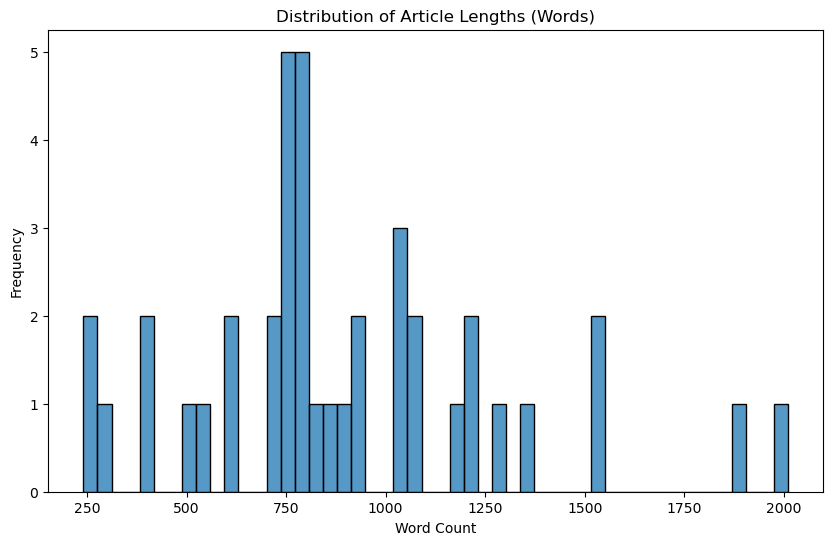

In [211]:
#ARTICLE LENGTH PLOT
plt.figure(figsize=(10,6))
sns.histplot(df['word_count'], bins=50)
plt.title("Distribution of Article Lengths (Words)")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.show()

# TEXT PREPROCESSING

In [213]:
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in stop_words and len(word) > 2]
    return " ".join(tokens)

In [215]:
df['clean_text'] = df['article_text'].apply(preprocess_text)

# WORD FREQUENCY

In [218]:
from collections import Counter
all_words = " ".join(df['clean_text']).split()
word_freq = Counter(all_words)
common_words = word_freq.most_common(20)
freq_df = pd.DataFrame(common_words, columns=['word','count'])

print(freq_df)

         word  count
0     climate    351
1      change    179
2        said    177
3      energy    108
4      global    102
5         new     92
6        also     92
7      report     85
8      people     83
9     weather     81
10      years     78
11      south     78
12       year     77
13     africa     71
14  emissions     68
15      water     65
16      world     62
17       wind     59
18    extreme     58
19      power     57


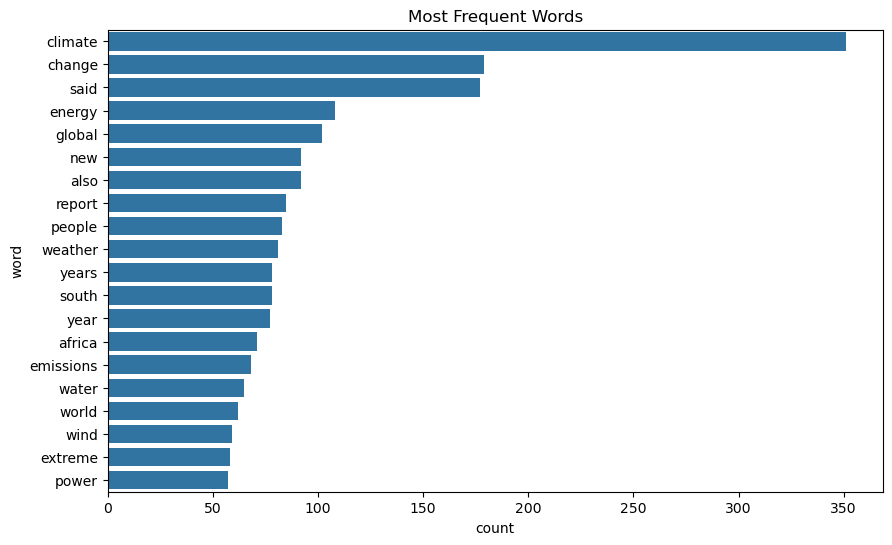

In [220]:
#WORD FREQUENCY PLOT
plt.figure(figsize=(10,6))
sns.barplot(data=freq_df, x='count', y='word')
plt.title("Most Frequent Words")
plt.show()

# WORD CLOUD

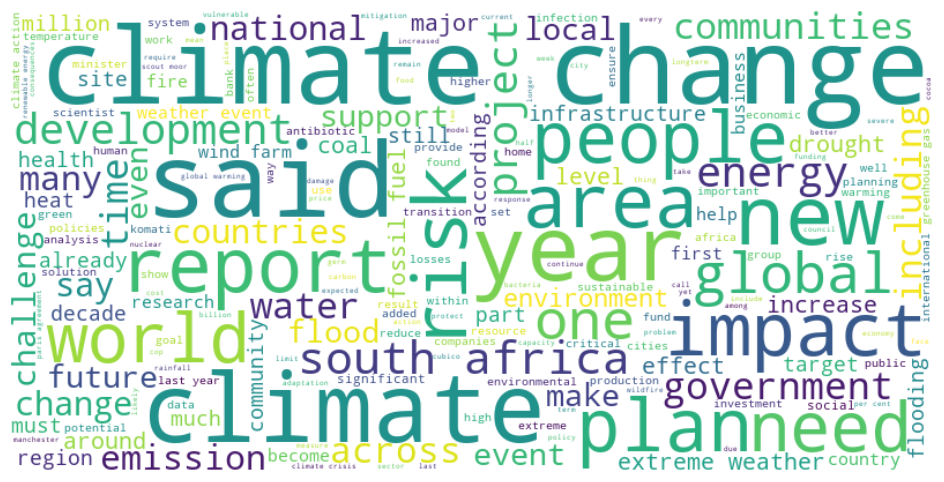

In [223]:
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(" ".join(df['clean_text']))

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

# TOPIC MODELLING (LDA)

In [225]:
vectorizer = CountVectorizer(
    max_df=0.9,
    min_df=10,
    stop_words='english'
)

dtm = vectorizer.fit_transform(df['clean_text'])

In [227]:
num_topics = 10

lda = LatentDirichletAllocation(
    n_components=num_topics,
    random_state=42
)

lda.fit(dtm)

LatentDirichletAllocation(random_state=42)

In [229]:
#MAIN WORDS PER TOPIC
words = vectorizer.get_feature_names_out()
for topic_idx, topic in enumerate(lda.components_):
    top_words = [words[i] for i in topic.argsort()[-10:]]
    
    print(f"\nTopic {topic_idx + 1}")
    print(top_words)


Topic 1
['people', 'local', 'area', 'research', 'renewable', 'important', 'new', 'public', 'support', 'energy']

Topic 2
['companies', 'energy', 'action', 'development', 'plan', 'need', 'national', 'green', 'risks', 'infrastructure']

Topic 3
['events', 'year', 'weather', 'sustainable', 'report', 'food', 'future', 'years', 'global', 'communities']

Topic 4
['communities', 'governments', 'gas', 'coal', 'government', 'fossil', 'africa', 'plan', 'power', 'south']

Topic 5
['ensure', 'development', 'reduce', 'government', 'policy', 'social', 'said', 'action', 'economic', 'economy']

Topic 6
['community', 'development', 'business', 'project', 'plans', 'area', 'energy', 'said', 'local', 'new']

Topic 7
['risk', 'years', 'year', 'heat', 'events', 'extreme', 'people', 'weather', 'water', 'said']

Topic 8
['carbon', 'agreement', 'said', 'greenhouse', 'gas', 'levels', 'report', 'warming', 'emissions', 'global']

Topic 9
['global', 'new', 'environmental', 'emissions', 'africa', 'south', 'power',

In [231]:
#TOPIC DISTR PER ARTICLE
topic_results = lda.transform(dtm)
topic_df = pd.DataFrame(topic_results)
topic_df.columns = [f"Topic_{i}" for i in range(num_topics)]
df = pd.concat([df, topic_df], axis=1)

#DOMINANT TOPIC
df['dominant_topic'] = topic_results.argmax(axis=1)

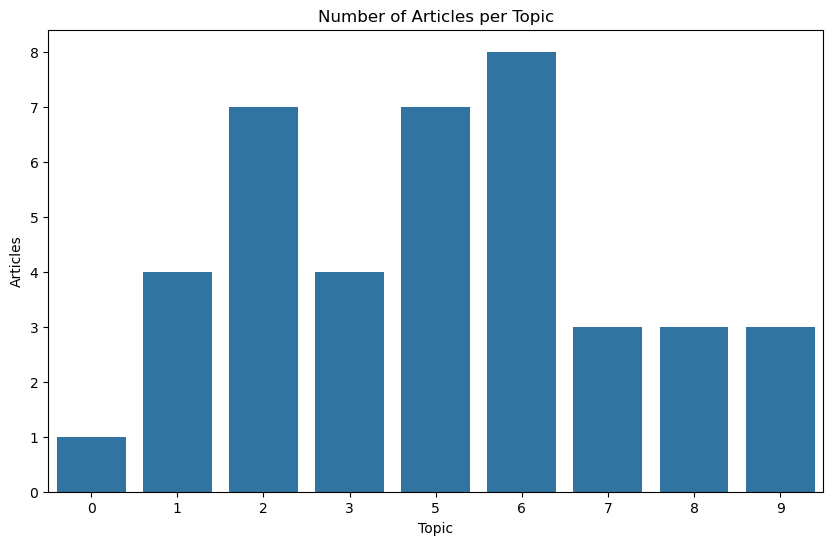

In [233]:
#TOPIC DISTRIBUTION
topic_counts = df['dominant_topic'].value_counts().sort_index()

plt.figure(figsize=(10,6))
sns.barplot(x=topic_counts.index, y=topic_counts.values)
plt.title("Number of Articles per Topic")
plt.xlabel("Topic")
plt.ylabel("Articles")
plt.show()

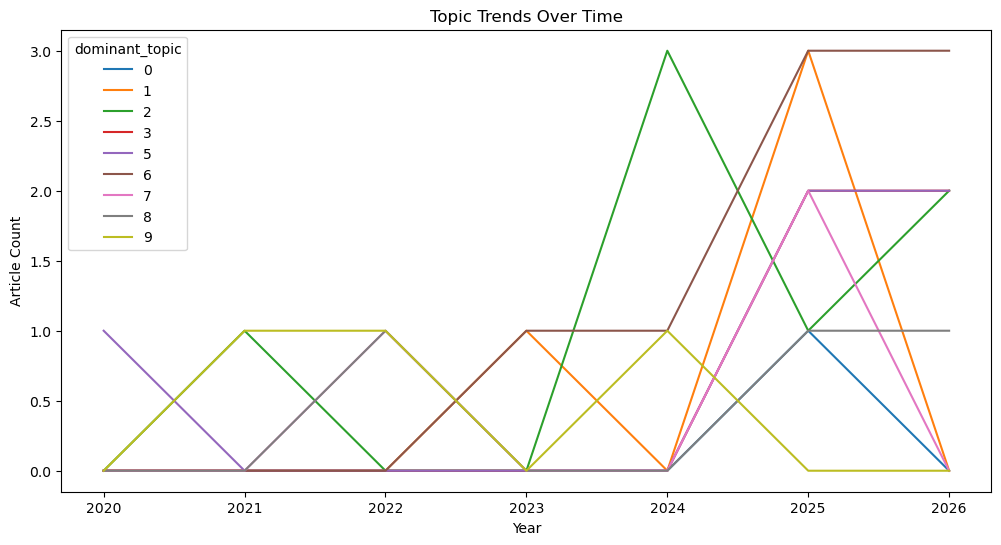

In [237]:
#TOPICS OVER TIME
df['year'] = df['date'].dt.year

topic_time = pd.crosstab(df['year'], df['dominant_topic'])

topic_time.plot(kind='line', figsize=(12,6))

plt.title("Topic Trends Over Time")
plt.xlabel("Year")
plt.ylabel("Article Count")
plt.show()

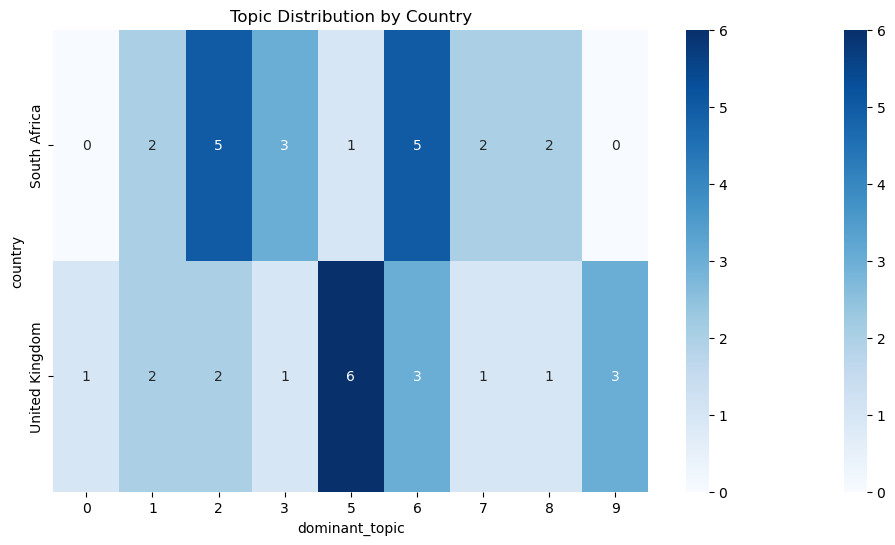

In [243]:
#TOPIC BY COUNTRY
topic_country = pd.crosstab(df['country'], df['dominant_topic'])
#print(topic_country)

#HEATMAP VISUALIZATION
plt.figure(figsize=(12,6))
sns.heatmap(topic_country, cmap="Blues", annot=True, fmt="d", linewidths=0.5 )
sns.heatmap(topic_country, cmap="Blues")
plt.title("Topic Distribution by Country")
plt.show()

In [245]:
#SAVE DATASET
df.to_csv("articles_combined.csv", index=False)